In [1]:
%load_ext autoreload
%autoreload 2

# Pefrom Wiener-SVD Unfolding

In [2]:
from os import path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')
from analysis_village.unfolding.utils import *

from var_config_cohpi import *


## 1. Open Covariance Files

In [3]:
genie_cov = np.load("flux_syst_cov_matrices.npz", allow_pickle=True)
syst_name = "Flux"

In [4]:
genie_cov['cov_ms_ms'].item()['cov']

array([[ 3.42803853e-85, -2.78184079e-86, -4.15614062e-85,
        -2.62523729e-86,  1.32802898e-85, -1.19785523e-85,
        -1.81096990e-85, -1.67091162e-85],
       [-2.78184079e-86,  1.81914616e-85,  5.43881691e-88,
        -8.41273838e-86, -6.98699269e-86,  1.17422145e-85,
         9.57167190e-86,  1.03977442e-85],
       [-4.15614062e-85,  5.43881691e-88,  1.52012430e-84,
         3.69825329e-85,  2.76690093e-87,  1.52351562e-85,
         1.42573084e-85,  7.67359977e-85],
       [-2.62523729e-86, -8.41273838e-86,  3.69825329e-85,
         2.84308383e-85,  1.03206829e-85, -5.79072966e-86,
        -7.88540894e-86,  1.11771068e-85],
       [ 1.32802898e-85, -6.98699269e-86,  2.76690093e-87,
         1.03206829e-85,  1.50914624e-85, -1.15943945e-85,
        -1.28763871e-85, -3.36301388e-86],
       [-1.19785523e-85,  1.17422145e-85,  1.52351562e-85,
        -5.79072966e-86, -1.15943945e-85,  2.68029149e-85,
         1.39544222e-85,  2.55728125e-85],
       [-1.81096990e-85,  9.571671

## 2. Asimov data test

### 2 - 1: Make Asimov data

In [5]:
## for asimov data stat unc. calculation
XSEC_UNIT = 7.038e-43

asimov_data_sr = genie_cov['bs'] + genie_cov['ms']
asimov_data_sb = genie_cov['bc'] + genie_cov['mc']
## stat. unc of asimov data in sqrt(N) approximation, converted to xsec unit
cov_asimov_data_sr = np.diag(asimov_data_sr * XSEC_UNIT)
cov_asimov_data_sb = np.diag(asimov_data_sb * XSEC_UNIT)

### 2 - 2: Plot Asimov data vs. MC plot

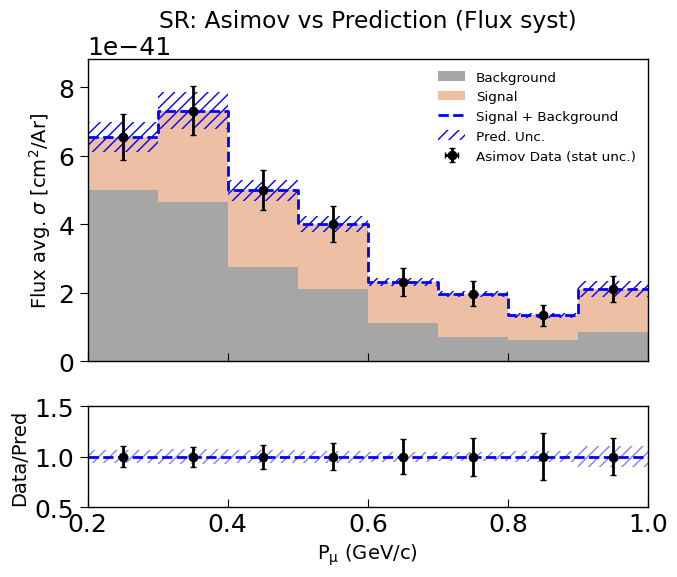

In [19]:
plot_overlay_with_cov(
    data=asimov_data_sr,
    cov_data=cov_asimov_data_sr,
    signal=genie_cov["ms"],
    cov_signal=genie_cov["cov_ms_ms"].item()["cov"],
    background=genie_cov["bs"],
    cov_background=genie_cov["cov_bs_bs"].item()["cov"],
    varcfg=varcfg_p_mu,
    title=f"SR: Asimov vs Prediction ({syst_name} syst)",
    data_label="Asimov Data (stat unc.)",
    y_label_top=r"Flux avg. $\sigma$ [cm$^2/\rm{Ar}$]",
    ratio_y_min=0.5,
    ratio_y_max=1.5,
)


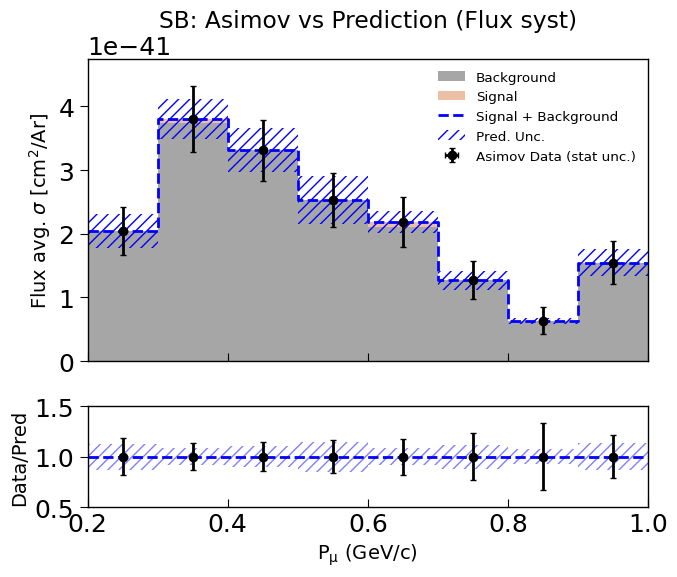

In [20]:
plot_overlay_with_cov(
    data=asimov_data_sb,
    cov_data=cov_asimov_data_sb,
    signal=genie_cov["mc"],
    cov_signal=genie_cov["cov_mc_mc"].item()["cov"],
    background=genie_cov["bc"],
    cov_background=genie_cov["cov_bc_bc"].item()["cov"],
    varcfg=varcfg_p_mu,
    title=f"SB: Asimov vs Prediction ({syst_name} syst)",
    data_label="Asimov Data (stat unc.)",
    y_label_top=r"Flux avg. $\sigma$ [cm$^2/\rm{Ar}$]",
    ratio_y_min=0.5,
    ratio_y_max=1.5,
)


### 2 - 3: CCBC

Merge SB asimov data's stat unc to total cov in SB

In [21]:
cov_cc = genie_cov["cov_mc_mc"].item()["cov"] + genie_cov["cov_bc_bc"].item()["cov"] + genie_cov["cov_mc_bc"].item()["cov"] + genie_cov["cov_bc_mc"].item()["cov"]
tilde_cov_cc = cov_cc + cov_asimov_data_sb

Constrained bs and cov_bs_bs

In [22]:
## since d_C - n_c^CV is zero, bs_const = genie_cov["bs"]
cov_bs_nc = (genie_cov["cov_bs_bc"].item()["cov"] + genie_cov["cov_bs_mc"].item()["cov"])
cov_bs_nc_T = cov_bs_nc.T
tilde_cov_cc_inv = collect_inv_cov(tilde_cov_cc)
bs_const = genie_cov["bs"] + cov_bs_nc @ tilde_cov_cc_inv @ (asimov_data_sb - genie_cov['bc'] - genie_cov['mc'])

In [23]:
cov_bs_bs_const = genie_cov["cov_bs_bs"].item()["cov"] - cov_bs_nc @ tilde_cov_cc_inv @ cov_bs_nc_T

Unconst vs. Const for Asimov - background: merge asimov stat unc to bkg cov

In [24]:
n_bins = len(varcfg_p_mu.bins) - 1
cov_zero = np.zeros((n_bins, n_bins))
arr_zero = np.zeros(n_bins)

asimov_m_bkg_sr = asimov_data_sr - genie_cov["bs"]
asimov_m_bkg_sr_const = asimov_data_sr - bs_const

cov_asimov_m_bkg_sr = genie_cov["cov_bs_bs"].item()["cov"] + cov_asimov_data_sr
cov_asimov_m_bkg_sr_const = cov_bs_bs_const + cov_asimov_data_sr

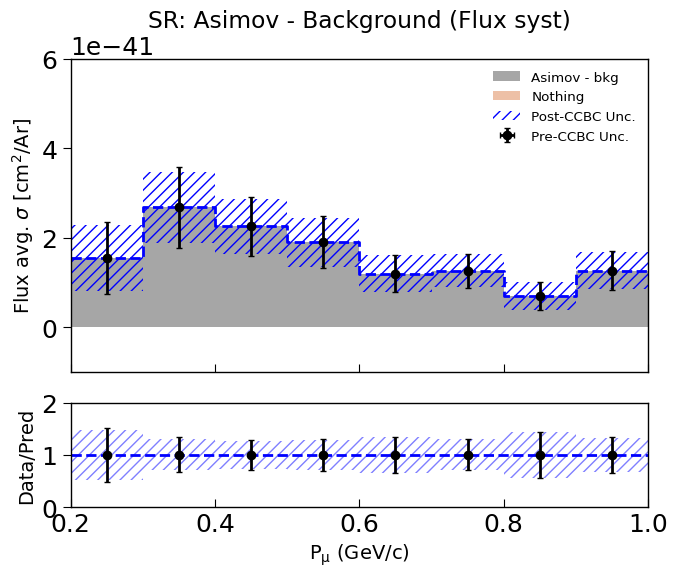

In [25]:
plot_overlay_with_cov(
    data=asimov_m_bkg_sr,
    cov_data=cov_asimov_m_bkg_sr,
    signal=arr_zero,
    cov_signal=cov_zero,
    background=asimov_m_bkg_sr_const,
    cov_background= cov_asimov_m_bkg_sr_const,
    varcfg=varcfg_p_mu,
    title=f"SR: Asimov - Background ({syst_name} syst)",
    ylims=(-1e-41, 6e-41),
    bkg_label="Asimov - bkg",
    sig_label="Nothing",
    sig_p_bkg_label="",
    pred_unc_label="Post-CCBC Unc.",
    data_label="Pre-CCBC Unc.",
    y_label_top=r"Flux avg. $\sigma$ [cm$^2/\rm{Ar}$]",
)
